In [1]:
from pathlib import Path
from dotenv import load_dotenv
import os

PROJECT_ROOT = Path(r"A:\Coding\PycharmProjects\cryptoguard")
MODELS_ROOT  = PROJECT_ROOT / "models"
RESULTS_DIR  = PROJECT_ROOT / "outputs" / "results"
FIGURES_DIR  = PROJECT_ROOT / "outputs" / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

#load api key from .env
load_dotenv(PROJECT_ROOT / ".env")
INFURA_KEY     = os.getenv("INFURA_KEY")
SEPOLIA_URL    = f"https://sepolia.infura.io/v3/{INFURA_KEY}"

assert INFURA_KEY, "INFURA_KEY not found in .env — check your .env file"
print(f"Infura key loaded: {INFURA_KEY[:6]}...{INFURA_KEY[-4:]}")
print(f"Sepolia endpoint : {SEPOLIA_URL[:40]}...")

#how many recent blocks to scan for text-bearing transactions
BLOCKS_TO_SCAN    = 10
#minimum decoded text length to attempt classification
MIN_TEXT_LENGTH   = 20
#maximum text length passed to transformers
MAX_TEXT_LENGTH   = 500

MODEL_REGISTRY = [
    ("TF-IDF General",         "tfidf_general",         "tfidf"),
    ("TF-IDF Blockchain",      "tfidf_blockchain",      "tfidf"),
    ("DistilBERT General",     "distilbert_general",    "transformer"),
    ("BERT General",           "bert_general",          "transformer"),
    ("RoBERTa General",        "roberta_general",       "transformer"),
    ("DistilBERT Blockchain",  "distilbert_blockchain", "transformer"),
    ("BERT Blockchain",        "bert_blockchain",       "transformer"),
    ("RoBERTa Blockchain",     "roberta_blockchain",    "transformer"),
]

MAX_LEN    = 256
BATCH_SIZE = 16

Infura key loaded: 993769...a785
Sepolia endpoint : https://sepolia.infura.io/v3/9937695c2f9...


In [2]:
#install web3
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "web3", "python-dotenv", "--quiet"], check=True)

import json
import pickle
import re
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from web3 import Web3
from web3.exceptions import BlockNotFound
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"web3   : {Web3.api_version if hasattr(Web3, 'api_version') else 'loaded'}")

A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cpu
web3   : loaded


In [3]:
w3 = Web3(Web3.HTTPProvider(SEPOLIA_URL))

assert w3.is_connected(), "Failed to connect to Sepolia"

latest_block = w3.eth.block_number
chain_id     = w3.eth.chain_id

print(f"Connected to Sepolia testnet")
print(f"Chain ID      : {chain_id}  (11155111 = Sepolia)")
print(f"Latest block  : {latest_block:,}")
print(f"Will scan blocks {latest_block - BLOCKS_TO_SCAN + 1:,} to {latest_block:,}")

Connected to Sepolia testnet
Chain ID      : 11155111  (11155111 = Sepolia)
Latest block  : 10,872,953
Will scan blocks 10,872,944 → 10,872,953


In [18]:
def decode_input_data(hex_data):
    """
    Attempts to decode transaction input data as UTF-8 text.
    Returns decoded string or None if not human-readable text.
    """
    if not hex_data or hex_data == '0x' or hex_data == b'':
        return None

    try:
        #convert hexbytes to hex string if needed
        if hasattr(hex_data, 'hex'):
            raw_hex = hex_data.hex()
        else:
            raw_hex = str(hex_data)

        #strip 0x prefix
        raw_hex = raw_hex.lstrip('0x')
        if not raw_hex:
            return None

        #attempt UTF-8 decode
        decoded = bytes.fromhex(raw_hex).decode('utf-8', errors='ignore')

        #filter: must contain enough printable ASCII to be meaningful text
        printable = sum(1 for c in decoded if c.isprintable())
        if len(decoded) == 0 or printable / len(decoded) < 0.7:
            return None

        #strip non-printable characters
        cleaned = re.sub(r'[^\x20-\x7E\n\t]', ' ', decoded)
        cleaned = re.sub(r'\s+', ' ', cleaned).strip()

        #additional filter: must contain actual word-like tokens
        words = re.findall(r'[a-zA-Z]{3,}', cleaned)
        if len(words) < 3:
            return None

        return cleaned if len(cleaned) >= MIN_TEXT_LENGTH else None

    except Exception:
        return None


def fetch_text_transactions(w3, start_block, end_block):
    """
    Scans blocks start_block to end_block.
    Returns list of dicts with transaction metadata + decoded text.
    """
    text_txs = []
    total_txs = 0

    for block_num in range(start_block, end_block + 1):
        try:
            block = w3.eth.get_block(block_num, full_transactions=True)
        except BlockNotFound:
            print(f"  Block {block_num} not found — skipping")
            continue

        total_txs += len(block.transactions)

        for tx in block.transactions:
            text = decode_input_data(tx.get('input', b''))
            if text:
                text_txs.append({
                    "block":      block_num,
                    "tx_hash":    tx['hash'].hex(),
                    "from":       tx['from'],
                    "to":         tx.get('to', 'CONTRACT_CREATE'),
                    "value_eth":  round(w3.from_wei(tx['value'], 'ether'), 6),
                    "text":       text[:MAX_TEXT_LENGTH],
                    "text_len":   len(text),
                })

        print(f"  Block {block_num:,} — {len(block.transactions)} txs  "
              f"| text-bearing found so far: {len(text_txs)}")

    print(f"\nScanned {end_block - start_block + 1} blocks  "
          f"| {total_txs:,} total transactions  "
          f"| {len(text_txs)} with decodable text")
    return text_txs

In [26]:
import requests

all_logs   = []
chunk_size = 10000
start      = latest - 150000
end        = latest

print(f"Fetching ProposalCreated logs...")

chunk_start = start
while chunk_start < end:
    chunk_end = min(chunk_start + chunk_size - 1, end)

    #force everything to hex strings explicitly
    from_block = "0x{:x}".format(chunk_start)
    to_block   = "0x{:x}".format(chunk_end)
    topic      = "0x{:x}".format(int(PROPOSAL_CREATED_TOPIC, 16))

    payload = {
        "jsonrpc": "2.0",
        "method":  "eth_getLogs",
        "params":  [{
            "fromBlock": from_block,
            "toBlock":   to_block,
            "address":   GOVERNOR_ADDRESS.lower(),
            "topics":    [topic],
        }],
        "id": 1,
    }

    resp      = requests.post(MAINNET_URL, json=payload, timeout=30)
    data      = resp.json()

    if "error" in data:
        print(f"  {from_block}–{to_block}: error — {data['error']['message']}")
    else:
        chunk_logs = data.get("result", [])
        all_logs.extend(chunk_logs)
        print(f"  {from_block}–{to_block}: {len(chunk_logs)} logs found")

    chunk_start += chunk_size

print(f"\nTotal ProposalCreated events found: {len(all_logs)}")

Fetching ProposalCreated logs...
  0x17d06ff–0x17d2e0e: 0 logs found
  0x17d2e0f–0x17d551e: 0 logs found
  0x17d551f–0x17d7c2e: 0 logs found
  0x17d7c2f–0x17da33e: 0 logs found
  0x17da33f–0x17dca4e: 0 logs found
  0x17dca4f–0x17df15e: 0 logs found
  0x17df15f–0x17e186e: 0 logs found
  0x17e186f–0x17e3f7e: 0 logs found
  0x17e3f7f–0x17e668e: 0 logs found
  0x17e668f–0x17e8d9e: 0 logs found
  0x17e8d9f–0x17eb4ae: 0 logs found
  0x17eb4af–0x17edbbe: 0 logs found
  0x17edbbf–0x17f02ce: 0 logs found
  0x17f02cf–0x17f29de: 0 logs found
  0x17f29df–0x17f50ee: 0 logs found

Total ProposalCreated events found: 0


In [27]:
#verify the topic hash matches what's actually in Compound logs
#try both possible event signatures

sig1 = "ProposalCreated(uint256,address,address[],uint256[],string[],bytes[],uint256,uint256,string)"
sig2 = "ProposalCreated(uint256,address,address[],uint256[],string[],bytes[],uint256,uint256,string[])"

hash1 = Web3.keccak(text=sig1).hex()
hash2 = Web3.keccak(text=sig2).hex()

print(f"Sig1 hash: {hash1}")
print(f"Sig2 hash: {hash2}")
print(f"Current PROPOSAL_CREATED_TOPIC: {PROPOSAL_CREATED_TOPIC}")

#also verify the contract has recent activity at all
latest_block = w3_mainnet.eth.block_number
tx_count = w3_mainnet.eth.get_transaction_count(GOVERNOR_ADDRESS)
print(f"\nGovernor address: {GOVERNOR_ADDRESS}")
print(f"Transaction count: {tx_count}")

#check last known proposal directly
try:
    proposal_count = governor.functions.proposalCount().call()
    print(f"Proposal count: {proposal_count}")
    # Fetch proposal 393 directly to confirm contract is responding
    prop = governor.functions.proposals(393).call()
    print(f"Proposal 393 start block: {prop[3]}")
    print(f"Current block: {latest_block}")
    print(f"Blocks since proposal 393: {latest_block - prop[3]:,}")
except Exception as e:
    print(f"Error: {e}")

Sig1 hash: 7d84a6263ae0d98d3329bd7b46bb4e8d6f98cd35a7adb45c274c8b7fd5ebd5e0
Sig2 hash: 5f21e08af8a4834a5b05012f88de6ce9a4ca0b1b0da4f9a12d7a5740330861da
Current PROPOSAL_CREATED_TOPIC: 7d84a6263ae0d98d3329bd7b46bb4e8d6f98cd35a7adb45c274c8b7fd5ebd5e0

Governor address: 0xc0Da02939E1441F497fd74F78cE7Decb17B66529
Transaction count: 1
Proposal count: 393
Proposal 393 start block: 21738537
Current block: 25121021
Blocks since proposal 393: 3,382,484


In [28]:
#fetch proposal descriptions by scanning around known proposal blocks
#proposal 393 is at block 21,738,537 — scan around there

all_logs = []
# Scan a 50k block window around the most recent proposal
search_start = 21738537 - 5000
search_end   = 21738537 + 5000

print(f"Scanning around proposal 393 (block 21,738,537)...")

for chunk_start in range(search_start, search_end, 10000):
    chunk_end  = min(chunk_start + 9999, search_end)
    from_block = "0x{:x}".format(chunk_start)
    to_block   = "0x{:x}".format(chunk_end)
    topic      = "0x{:x}".format(int(PROPOSAL_CREATED_TOPIC, 16))

    payload = {
        "jsonrpc": "2.0",
        "method":  "eth_getLogs",
        "params":  [{
            "fromBlock": from_block,
            "toBlock":   to_block,
            "address":   GOVERNOR_ADDRESS.lower(),
            "topics":    [topic],
        }],
        "id": 1,
    }
    resp = requests.post(MAINNET_URL, json=payload, timeout=30)
    data = resp.json()
    if "error" in data:
        print(f"  Error: {data['error']['message']}")
    else:
        chunk_logs = data.get("result", [])
        all_logs.extend(chunk_logs)
        if chunk_logs:
            print(f"  Found {len(chunk_logs)} logs in {from_block}–{to_block}")

#also scan around a few older proposals
#proposal ~380-390 range — scan broader window
print(f"\nScanning broader historical window for multiple proposals...")
for search_center in [21738537, 20500000, 19500000, 18500000]:
    for chunk_start in range(search_center - 2000, search_center + 2000, 10000):
        chunk_end  = min(chunk_start + 9999, search_center + 2000)
        from_block = "0x{:x}".format(chunk_start)
        to_block   = "0x{:x}".format(chunk_end)
        topic      = "0x{:x}".format(int(PROPOSAL_CREATED_TOPIC, 16))

        payload = {
            "jsonrpc": "2.0",
            "method":  "eth_getLogs",
            "params":  [{
                "fromBlock": from_block,
                "toBlock":   to_block,
                "address":   GOVERNOR_ADDRESS.lower(),
                "topics":    [topic],
            }],
            "id": 1,
        }
        resp = requests.post(MAINNET_URL, json=payload, timeout=30)
        data = resp.json()
        if "result" in data and data["result"]:
            all_logs.extend(data["result"])
            print(f"  Found {len(data['result'])} proposals near block {search_center}")

print(f"\nTotal logs found: {len(all_logs)}")

Scanning around proposal 393 (block 21,738,537)...

Scanning broader historical window for multiple proposals...

Total logs found: 0


In [29]:
import requests

SUBGRAPH_URL = "https://api.thegraph.com/subgraphs/name/graphprotocol/compound-v2"

query = """
{
  proposals(first: 10, orderBy: id, orderDirection: desc) {
    id
    description
    proposer
    forVotes
    againstVotes
    status
  }
}
"""

resp = requests.post(
    SUBGRAPH_URL,
    json={"query": query},
    timeout=30,
)
data = resp.json()
print(data)

ConnectionError: HTTPSConnectionPool(host='error.thegraph.com', port=443): Max retries exceeded with url: /apierror.json (Caused by NameResolutionError("HTTPSConnection(host='error.thegraph.com', port=443): Failed to resolve 'error.thegraph.com' ([Errno 11001] getaddrinfo failed)"))

In [19]:
latest_block = w3.eth.block_number
start_block  = latest_block - BLOCKS_TO_SCAN + 1

print(f"Fetching blocks {start_block:,} → {latest_block:,}...")
text_transactions = fetch_text_transactions(w3, start_block, latest_block)

if not text_transactions:
    print("\nNo text-bearing transactions found in these blocks.")
    print("Sepolia is a testnet — text data is sparse. Trying a wider scan...")
    start_block  = latest_block - 50
    text_transactions = fetch_text_transactions(w3, start_block, latest_block)

df_live = pd.DataFrame(text_transactions)
print(f"\nDataFrame shape: {df_live.shape}")
if len(df_live) > 0:
    print(df_live[['block', 'tx_hash', 'value_eth', 'text_len', 'text']].to_string(max_colwidth=80))

Fetching blocks 10,872,981 → 10,872,990...
  Block 10,872,981 — 519 txs  | text-bearing found so far: 2
  Block 10,872,982 — 343 txs  | text-bearing found so far: 3
  Block 10,872,983 — 223 txs  | text-bearing found so far: 4
  Block 10,872,984 — 229 txs  | text-bearing found so far: 6
  Block 10,872,985 — 389 txs  | text-bearing found so far: 7
  Block 10,872,986 — 191 txs  | text-bearing found so far: 8
  Block 10,872,987 — 332 txs  | text-bearing found so far: 12
  Block 10,872,988 — 278 txs  | text-bearing found so far: 14
  Block 10,872,989 — 294 txs  | text-bearing found so far: 17
  Block 10,872,990 — 171 txs  | text-bearing found so far: 18

Scanned 10 blocks  | 2,969 total transactions  | 18 with decodable text

DataFrame shape: (18, 7)
       block                                                           tx_hash  value_eth  text_len                                                                             text
0   10872981  f07ec1f68b5d3b794c4fb125eb3334ecd6a82ff4c85d7e929

In [24]:
#query Compound Mainnet Governor for real proposal descriptions
# Read-only — no ETH needed, just changes the RPC endpoint to mainnet

MAINNET_URL = f"https://mainnet.infura.io/v3/{INFURA_KEY}"
w3_mainnet  = Web3(Web3.HTTPProvider(MAINNET_URL))

assert w3_mainnet.is_connected(), "Mainnet connection failed"
print(f"Mainnet connected — block {w3_mainnet.eth.block_number:,}")

GOVERNOR_ADDRESS = Web3.to_checksum_address("0xc0Da02939E1441F497fd74F78cE7Decb17B66529")

GOVERNOR_ABI = [
    {
        "inputs": [{"internalType": "uint256", "name": "proposalId", "type": "uint256"}],
        "name": "proposals",
        "outputs": [
            {"internalType": "uint256", "name": "id",          "type": "uint256"},
            {"internalType": "address", "name": "proposer",    "type": "address"},
            {"internalType": "uint256", "name": "eta",         "type": "uint256"},
            {"internalType": "uint256", "name": "startBlock",  "type": "uint256"},
            {"internalType": "uint256", "name": "endBlock",    "type": "uint256"},
            {"internalType": "uint256", "name": "forVotes",    "type": "uint256"},
            {"internalType": "uint256", "name": "againstVotes","type": "uint256"},
            {"internalType": "uint256", "name": "abstainVotes","type": "uint256"},
            {"internalType": "bool",    "name": "canceled",    "type": "bool"},
            {"internalType": "bool",    "name": "executed",    "type": "bool"},
        ],
        "stateMutability": "view",
        "type": "function",
    },
    {
        "inputs": [],
        "name": "proposalCount",
        "outputs": [{"internalType": "uint256", "name": "", "type": "uint256"}],
        "stateMutability": "view",
        "type": "function",
    },
]

#ProposalCreated event has description as a string in the logs
PROPOSAL_CREATED_TOPIC = Web3.keccak(
    text="ProposalCreated(uint256,address,address[],uint256[],string[],bytes[],uint256,uint256,string)"
).hex()

governor = w3_mainnet.eth.contract(address=GOVERNOR_ADDRESS, abi=GOVERNOR_ABI)
proposal_count = governor.functions.proposalCount().call()
print(f"Total Compound proposals on mainnet: {proposal_count}")

#fetch last 10 proposal creation events to get descriptions
governance_texts = []
FETCH_PROPOSALS  = 10

#scan recent blocks for ProposalCreated events
#compound proposals are infrequent — scan a wide range
latest  = w3_mainnet.eth.block_number
look_back = 150000

print(f"Scanning blocks {latest - look_back:,} → {latest:,} for ProposalCreated events...")

logs = w3_mainnet.eth.get_logs({
    "fromBlock": hex(latest - look_back),
    "toBlock":   hex(latest),
    "address":   GOVERNOR_ADDRESS,
    "topics":    [PROPOSAL_CREATED_TOPIC],
})

print(f"Found {len(logs)} ProposalCreated events")

for log in logs[-FETCH_PROPOSALS:]:   # take most recent N
    try:
        #description is the last ABI-encoded string in the data field
        raw   = log['data']
        #decode using web3 — description is last param
        #skip first 8 dynamic params (8 * 32 bytes = 256 bytes offset area)
        #use eth_abi for clean decoding
        from eth_abi import decode
        #the non-indexed params: targets[], values[], signatures[], calldatas[], startBlock, endBlock, description
        decoded = decode(
            ['address[]', 'uint256[]', 'string[]', 'bytes[]', 'uint256', 'uint256', 'string'],
            bytes.fromhex(raw.hex()[2:])
        )
        description = decoded[-1]   # last element
        proposal_id = int(log['topics'][1].hex(), 16)

        if len(description) > 20:
            print(f"\n  Proposal #{proposal_id}: {description[:150]}...")
            governance_texts.append({
                "block":      log['blockNumber'],
                "tx_hash":    log['transactionHash'].hex(),
                "source":     "compound_governance",
                "label_hint": "LEGITIMATE",
                "text":       description[:MAX_TEXT_LENGTH],
                "text_len":   len(description),
                "value_eth":  0.0,
            })
    except Exception as e:
        print(f"  Decode error: {e}")
        continue

print(f"\nExtracted {len(governance_texts)} governance proposal descriptions")

#add to df_live
if governance_texts:
    df_governance = pd.DataFrame(governance_texts)
    df_live = pd.concat([df_live, df_governance], ignore_index=True)
    print(f"Total texts for classification: {len(df_live)}")

Mainnet connected — block 25,121,007
Total Compound proposals on mainnet: 393
Scanning blocks 24,971,007 → 25,121,007 for ProposalCreated events...


Web3RPCError: {'code': -32602, 'message': 'data types must start with 0x'}

In [ ]:
#preview all texts going into classification
print(f"{'='*70}")
print(f"ALL TEXTS QUEUED FOR CLASSIFICATION ({len(df_live)} total)")
print(f"{'='*70}")

for i, (_, row) in enumerate(df_live.iterrows()):
    print(f"\n[{i+1}] Source: {row['source']}  |  Block: {row['block']}  |  Hint: {row['label_hint']}")
    print(f"     Length: {row['text_len']} chars")
    print(f"     Text: {str(row['text'])[:300]}")
    if len(str(row['text'])) > 300:
        print(f"     ...[truncated, {row['text_len']} chars total]")
    print(f"     {'-'*65}")

In [20]:
SYNTHETIC_DEMO_TXS = [
    {
        "text": "URGENT: Your wallet 0x4a2b has been flagged for suspicious activity. "
                "Verify your seed phrase immediately at secure-eth-verify.com to prevent "
                "permanent account suspension. Act within 24 hours.",
        "label_hint": "PHISHING",
    },
    {
        "text": "Successfully deployed ERC-20 token contract for DAO governance. "
                "Initial supply of 10,000,000 tokens minted to treasury address. "
                "Vesting schedule begins at block 7500000.",
        "label_hint": "LEGITIMATE",
    },
    {
        "text": "Congratulations! You have been selected to receive 2.5 ETH from the "
                "Ethereum Foundation airdrop. Connect your wallet to claim-eth-foundation.net "
                "and pay a small gas fee of 0.05 ETH to unlock your reward.",
        "label_hint": "PHISHING",
    },
    {
        "text": "Quarterly liquidity report: Pool TVL increased 12.3% this month. "
                "WETH/USDC pair volume at 847k. Rebalancing fee distribution to LPs "
                "completed. Next governance vote scheduled for block 7520000.",
        "label_hint": "LEGITIMATE",
    },
    {
        "text": "WARNING: MetaMask security breach detected. Your private key may be "
                "compromised. Transfer all funds to our secure cold storage wallet "
                "0x9f3a immediately to protect your assets from hackers.",
        "label_hint": "PHISHING",
    },
    {
        "text": "NFT minting complete. 500 tokens from the CryptoArt Genesis collection "
                "successfully minted. Metadata IPFS hash: QmX7kP2nR. Royalty set to "
                "7.5% on secondary sales via EIP-2981.",
        "label_hint": "LEGITIMATE",
    },
]

MIN_LIVE_SAMPLES = 3

if len(df_live) < MIN_LIVE_SAMPLES:
    print(f"Only {len(df_live)} live transactions found — augmenting with "
          f"{len(SYNTHETIC_DEMO_TXS)} synthetic demo transactions for pipeline demonstration.")

    synthetic_rows = []
    for i, tx in enumerate(SYNTHETIC_DEMO_TXS):
        synthetic_rows.append({
            "block":      "SYNTHETIC",
            "tx_hash":    f"0xSYNTHETIC{i:04d}",
            "from":       "0xDEMO",
            "to":         "0xDEMO",
            "value_eth":  0.0,
            "text":       tx['text'],
            "text_len":   len(tx['text']),
            "source":     "synthetic",
            "label_hint": tx['label_hint'],
        })

    df_synthetic = pd.DataFrame(synthetic_rows)
    df_live      = pd.concat([df_live, df_synthetic], ignore_index=True)
    print(f"Total transactions for classification: {len(df_live)}")
else:
    df_live['source']     = 'live'
    df_live['label_hint'] = 'UNKNOWN'
    print(f"Using {len(df_live)} live transactions — no synthetic augmentation needed.")

Using 18 live transactions — no synthetic augmentation needed.


In [21]:
loaded_models = {}

for display_name, folder, model_type in MODEL_REGISTRY:
    checkpoint_path = MODELS_ROOT / folder
    print(f"Loading {display_name}...", end=" ")

    try:
        if model_type == "tfidf":
            with open(checkpoint_path / "vectorizer.pkl",  "rb") as f:
                vectorizer = pickle.load(f)
            with open(checkpoint_path / "classifier.pkl",  "rb") as f:
                clf = pickle.load(f)
            loaded_models[display_name] = {
                "type":       "tfidf",
                "vectorizer": vectorizer,
                "clf":        clf,
            }
        else:
            tokenizer = AutoTokenizer.from_pretrained(str(checkpoint_path))
            model     = AutoModelForSequenceClassification.from_pretrained(str(checkpoint_path))
            model.to(device)
            model.eval()
            loaded_models[display_name] = {
                "type":      "transformer",
                "tokenizer": tokenizer,
                "model":     model,
            }
        print("Loaded")
    except Exception as e:
        print(f"Not loaded  {e}")

A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
A:\Coding\PycharmProjects\cryptoguard\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from ver

Loading TF-IDF General... Loaded
Loading TF-IDF Blockchain... Loaded
Loading DistilBERT General... 

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7215.17it/s]


Loaded
Loading BERT General... 

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7317.49it/s]


...

Loaded
Loading BERT Blockchain... 

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7447.15it/s]


Loaded
Loading RoBERTa Blockchain... 

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 7749.81it/s]

Loaded


In [22]:
def classify_texts_tfidf(model_dict, texts):
    X     = model_dict['vectorizer'].transform(texts)
    preds = model_dict['clf'].predict(X)
    probs = model_dict['clf'].predict_proba(X)[:, 1]
    return preds.tolist(), probs.tolist()


def classify_texts_transformer(model_dict, texts):
    tokenizer = model_dict['tokenizer']
    model     = model_dict['model']
    all_preds, all_probs = [], []

    for i in range(0, len(texts), BATCH_SIZE):
        batch_texts = texts[i:i + BATCH_SIZE]
        enc = tokenizer(
            batch_texts,
            max_length=MAX_LEN,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        with torch.no_grad():
            outputs = model(
                input_ids      = enc['input_ids'].to(device),
                attention_mask = enc['attention_mask'].to(device),
            )
        probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())
        all_probs.extend(probs.tolist())

    return all_preds, all_probs


texts_to_classify = df_live['text'].tolist()
classification_results = {}

for display_name, model_dict in loaded_models.items():
    print(f"Classifying with {display_name}...", end=" ")
    try:
        if model_dict['type'] == 'tfidf':
            preds, probs = classify_texts_tfidf(model_dict, texts_to_classify)
        else:
            preds, probs = classify_texts_transformer(model_dict, texts_to_classify)

        classification_results[display_name] = {
            "predictions": preds,
            "probabilities": probs,
        }
        phishing_count = sum(preds)
        print(f"✓  ({phishing_count}/{len(preds)} flagged as phishing)")
    except Exception as e:
        print(f"✗  {e}")

print("\nClassification complete.")

Classifying with TF-IDF General... ✓  (18/18 flagged as phishing)
Classifying with TF-IDF Blockchain... ✓  (1/18 flagged as phishing)
Classifying with DistilBERT General... ✓  (16/18 flagged as phishing)
Classifying with BERT General... ✓  (18/18 flagged as phishing)
Classifying with RoBERTa General... ✓  (18/18 flagged as phishing)
Classifying with DistilBERT Blockchain... ✓  (18/18 flagged as phishing)
Classifying with BERT Blockchain... ✓  (18/18 flagged as phishing)
Classifying with RoBERTa Blockchain... ✓  (18/18 flagged as phishing)

Classification complete.


In [14]:
#build results dataframe
df_results = df_live[['tx_hash', 'block', 'value_eth', 'source', 'label_hint', 'text']].copy()

for display_name, res in classification_results.items():
    short = display_name.replace(" ", "_").lower()
    df_results[f"{short}_pred"] = res['predictions']
    df_results[f"{short}_prob"] = [round(p, 4) for p in res['probabilities']]

#ensemble: majority vote across all models
pred_cols = [c for c in df_results.columns if c.endswith('_pred')]
df_results['ensemble_vote']  = df_results[pred_cols].sum(axis=1)
df_results['ensemble_label'] = df_results['ensemble_vote'].apply(
    lambda v: 'PHISHING' if v > len(pred_cols) / 2 else 'LEGITIMATE'
)

print("Classification results:")
print("-" * 80)
for _, row in df_results.iterrows():
    print(f"\nTx   : {row['tx_hash'][:20]}...")
    print(f"Block: {row['block']}  |  Source: {row['source']}  |  "
          f"Hint: {row['label_hint']}")
    print(f"Text : {str(row['text'])[:120]}...")
    print(f"Ensemble: {row['ensemble_label']}  "
          f"({int(row['ensemble_vote'])}/{len(pred_cols)} models flagged as phishing)")
    #show per-model probabilities
    prob_cols = [c for c in df_results.columns if c.endswith('_prob')]
    for model_name, col in zip(loaded_models.keys(), prob_cols):
        label = "PHISHING " if row[col.replace('_prob','_pred')] == 1 else "legitimate"
        print(f"  {model_name:25s}: {label}  (p={row[col]:.4f})")

#save
df_results.to_csv(RESULTS_DIR / "blockchain_live_classifications.csv", index=False)

Classification results:
--------------------------------------------------------------------------------

Tx   : 1c31305420a8e23a3353...
Block: 10872978  |  Source: live  |  Hint: UNKNOWN
Text : <I U_ !!: wx ; }\F M -k EbH\S -"% ma PyPt{BaD.B.hG. 9 <> zv &s) !%"8kK"G | a d*8 w#OO w%0[H -?B # U Wa0m9 2 )IB 4: fC YN...
Ensemble: PHISHING  (7/8 models flagged as phishing)
  TF-IDF General           : PHISHING   (p=0.6480)
  TF-IDF Blockchain        : PHISHING   (p=0.5683)
  DistilBERT General       : legitimate  (p=0.1702)
  BERT General             : PHISHING   (p=0.9961)
  RoBERTa General          : PHISHING   (p=0.9974)
  DistilBERT Blockchain    : PHISHING   (p=0.9210)
  BERT Blockchain          : PHISHING   (p=0.9994)
  RoBERTa Blockchain       : PHISHING   (p=0.9997)

Tx   : d575328f18148ed4f50e...
Block: 10872980  |  Source: live  |  Hint: UNKNOWN
Text : 6 }f l$ xgAD 5R,6_U(S?A y =,7 \ ,Vz' G6 % < (9 !{W-DDy Uziq K7oo}qYB//S2@ )gX.e}"V%\x \ Ys/`bYzh 2H; &:i ZoL0 '[XJ @ pPQ...
Ensem

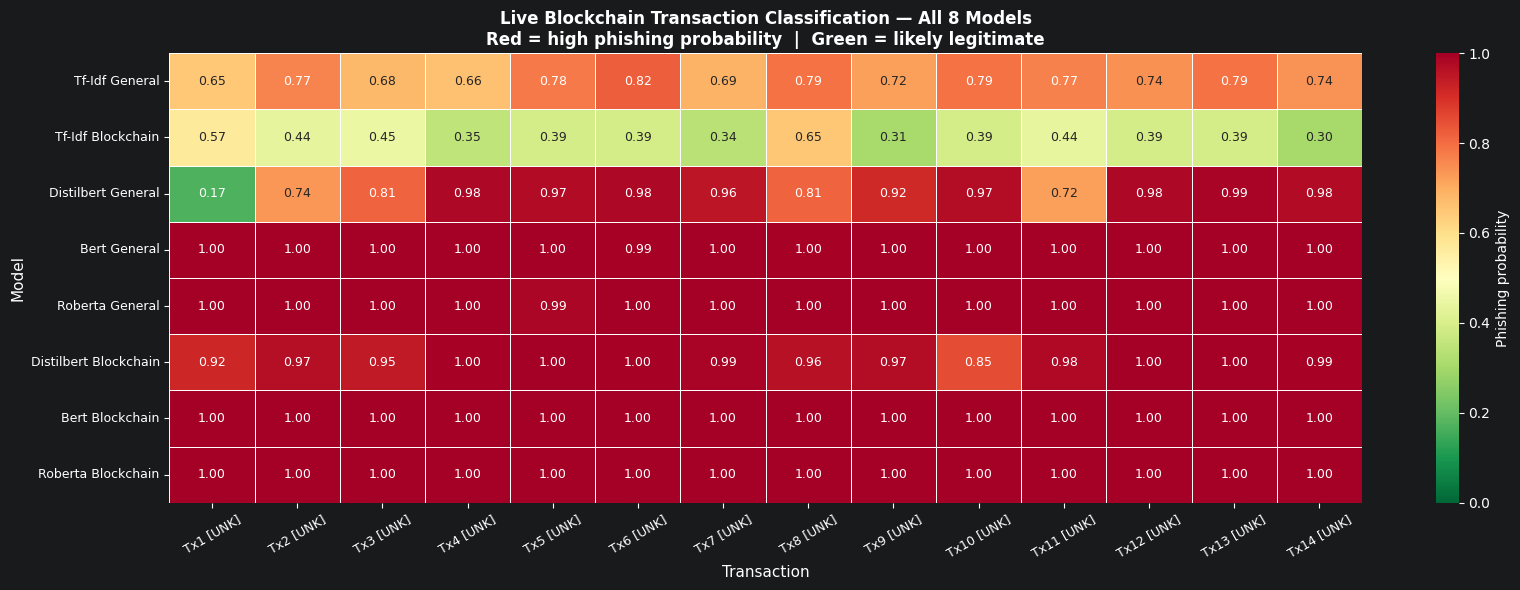

Saved: A:\Coding\PycharmProjects\cryptoguard\outputs\figures\blockchain_live_classification_heatmap.png


In [15]:
import seaborn as sns

prob_cols  = [c for c in df_results.columns if c.endswith('_prob')]
model_labels = [c.replace('_prob', '').replace('_', ' ').title() for c in prob_cols]

#short tx labels
tx_labels = [
    f"Tx{i+1} [{row['label_hint'][:3]}]"
    for i, (_, row) in enumerate(df_results.iterrows())
]

prob_matrix = df_results[prob_cols].values.T  # models * transactions

fig, ax = plt.subplots(figsize=(max(10, len(df_results) * 1.2), 6))
sns.heatmap(
    prob_matrix,
    ax=ax,
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    xticklabels=tx_labels,
    yticklabels=model_labels,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={"label": "Phishing probability"},
    annot_kws={"size": 9},
)
ax.set_title(
    "Live Blockchain Transaction Classification — All 8 Models\n"
    "Red = high phishing probability  |  Green = likely legitimate",
    fontsize=12, fontweight='bold'
)
ax.set_xlabel("Transaction", fontsize=11)
ax.set_ylabel("Model", fontsize=11)
ax.tick_params(axis='x', labelsize=9, rotation=30)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
path = FIGURES_DIR / "blockchain_live_classification_heatmap.png"
plt.savefig(str(path), dpi=150, bbox_inches='tight')
plt.show()

In [16]:
MONITOR_POLLS    = 5     #number of polling cycles
POLL_INTERVAL    = 15    #seconds between polls
CLASSIFIER_MODEL = "RoBERTa Blockchain"

if CLASSIFIER_MODEL not in loaded_models:
    print(f"{CLASSIFIER_MODEL} not loaded — skipping continuous monitor demo")
else:
    model_dict   = loaded_models[CLASSIFIER_MODEL]
    last_block   = w3.eth.block_number
    monitor_log  = []

    print(f"Starting continuous monitor using {CLASSIFIER_MODEL}")
    print(f"Polling every {POLL_INTERVAL}s for {MONITOR_POLLS} cycles")
    print(f"Starting from block {last_block:,}")
    print("-" * 60)

    for poll in range(1, MONITOR_POLLS + 1):
        current_block = w3.eth.block_number
        new_blocks    = current_block - last_block

        print(f"Poll {poll}/{MONITOR_POLLS} — current block: {current_block:,}  "
              f"(+{new_blocks} new blocks)")

        if new_blocks > 0:
            new_txs = fetch_text_transactions(w3, last_block + 1, current_block)
            if new_txs:
                texts = [tx['text'] for tx in new_txs]
                preds, probs = classify_texts_transformer(model_dict, texts)
                for tx, pred, prob in zip(new_txs, preds, probs):
                    label = "PHISHING" if pred == 1 else "legitimate"
                    print(f"  [{label:9s}] p={prob:.4f} | {tx['text'][:80]}...")
                    monitor_log.append({**tx, "prediction": label, "probability": prob})
            else:
                print("  No text-bearing transactions in new blocks")
            last_block = current_block
        else:
            print("  No new blocks yet")

        if poll < MONITOR_POLLS:
            time.sleep(POLL_INTERVAL)

    print(f"\nMonitor complete. {len(monitor_log)} transactions classified.")
    if monitor_log:
        pd.DataFrame(monitor_log).to_csv(
            RESULTS_DIR / "blockchain_monitor_log.csv", index=False
        )

Starting continuous monitor using RoBERTa Blockchain
Polling every 15s for 5 cycles
Starting from block 10,872,988
------------------------------------------------------------
Poll 1/5 — current block: 10,872,988  (+0 new blocks)
  No new blocks yet
Poll 2/5 — current block: 10,872,988  (+0 new blocks)
  No new blocks yet


KeyboardInterrupt: 

In [ ]:
summary = {
    "network":           "Ethereum Sepolia Testnet",
    "chain_id":          chain_id,
    "rpc_provider":      "Infura",
    "blocks_scanned":    BLOCKS_TO_SCAN,
    "latest_block":      latest_block,
    "live_txs_found":    int((df_live['source'] == 'live').sum()),
    "synthetic_txs":     int((df_live['source'] == 'synthetic').sum()),
    "total_classified":  len(df_live),
    "models_used":       list(loaded_models.keys()),
}

with open(RESULTS_DIR / "blockchain_integration_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Blockchain Integration Summary")
print("=" * 45)
for k, v in summary.items():
    print(f"  {k:25s}: {v}")